# Лабораторная работа №2
## «Виртуальный датчик для контроля процесса обжига в печи»

**Задача:** Прогнозировать концентрацию выходного продукта в реальном времени по минутным показателям телеметрии, заменяя запоздалые лабораторные замеры.

**Данные:**
- `data_train.csv` — 5-минутные измерения 16 телеметрических показателей за ~8 месяцев
- `target_train.csv` — нерегулярные лабораторные замеры концентрации (с задержкой 10–15 мин)
- `data_test_small.csv`, `target_test_small.csv` — аналогичные данные для тестирования

**Структура по ТЗ:**
- **2.1** Разведочный анализ данных (EDA)
- **2.2** Инжиниринг признаков
- **2.3** Построение и обоснование моделей (≥3 модели)
- **2.3** Оценка качества (MAE, RMSE, MAPE, WAPE, направление, SHAP)
- **2.4** Документирование и интерпретация

In [1]:
# ── Импорты ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
import shap

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [2]:
# ── Загрузка данных ───────────────────────────────────────────────────────────
data_train  = pd.read_csv('data_train.csv',       parse_dates=['timestamp'], index_col='timestamp')
target_train= pd.read_csv('target_train.csv',     parse_dates=['timestamp'])
data_test   = pd.read_csv('data_test_small.csv',  parse_dates=['timestamp'], index_col='timestamp')
target_test = pd.read_csv('target_test_small.csv',parse_dates=['timestamp'])

target_train = target_train.set_index('timestamp').sort_index()
target_test  = target_test.set_index('timestamp').sort_index()

print('=== Телеметрия (train) ===')
print(f'Период : {data_train.index[0]} — {data_train.index[-1]}')
print(f'Строк  : {len(data_train):,}, Признаков: {data_train.shape[1]}')
print(f'\n=== Целевая (train) ===')
print(f'Замеров: {len(target_train):,}')
print(f'Период : {target_train.index[0]} — {target_train.index[-1]}')
print(f'\n=== Телеметрия (test) ===')
print(f'Строк  : {len(data_test):,}')
print(f'\nПризнаки: {list(data_train.columns)}')

=== Телеметрия (train) ===
Период : 2023-01-01 00:00:00 — 2023-08-31 23:55:00
Строк  : 69,984, Признаков: 16

=== Целевая (train) ===
Замеров: 15,559
Период : 2023-01-01 00:30:00 — 2023-08-31 23:55:00

=== Телеметрия (test) ===
Строк  : 4,032

Признаки: ['temp_zone_1', 'temp_zone_2', 'temp_zone_3', 'temp_zone_4', 'feed_rate', 'rotation_speed', 'pressure_1', 'pressure_2', 'pressure_3', 'gas_consumption', 'o2_flue', 'co_flue', 'raw_humidity', 'temp_flue', 'vibration', 'drive_load']


---
## 2.1 Разведочный анализ данных (EDA)

### 2.1.1 Визуальный анализ телеметрии: тренды, сезонность, выбросы

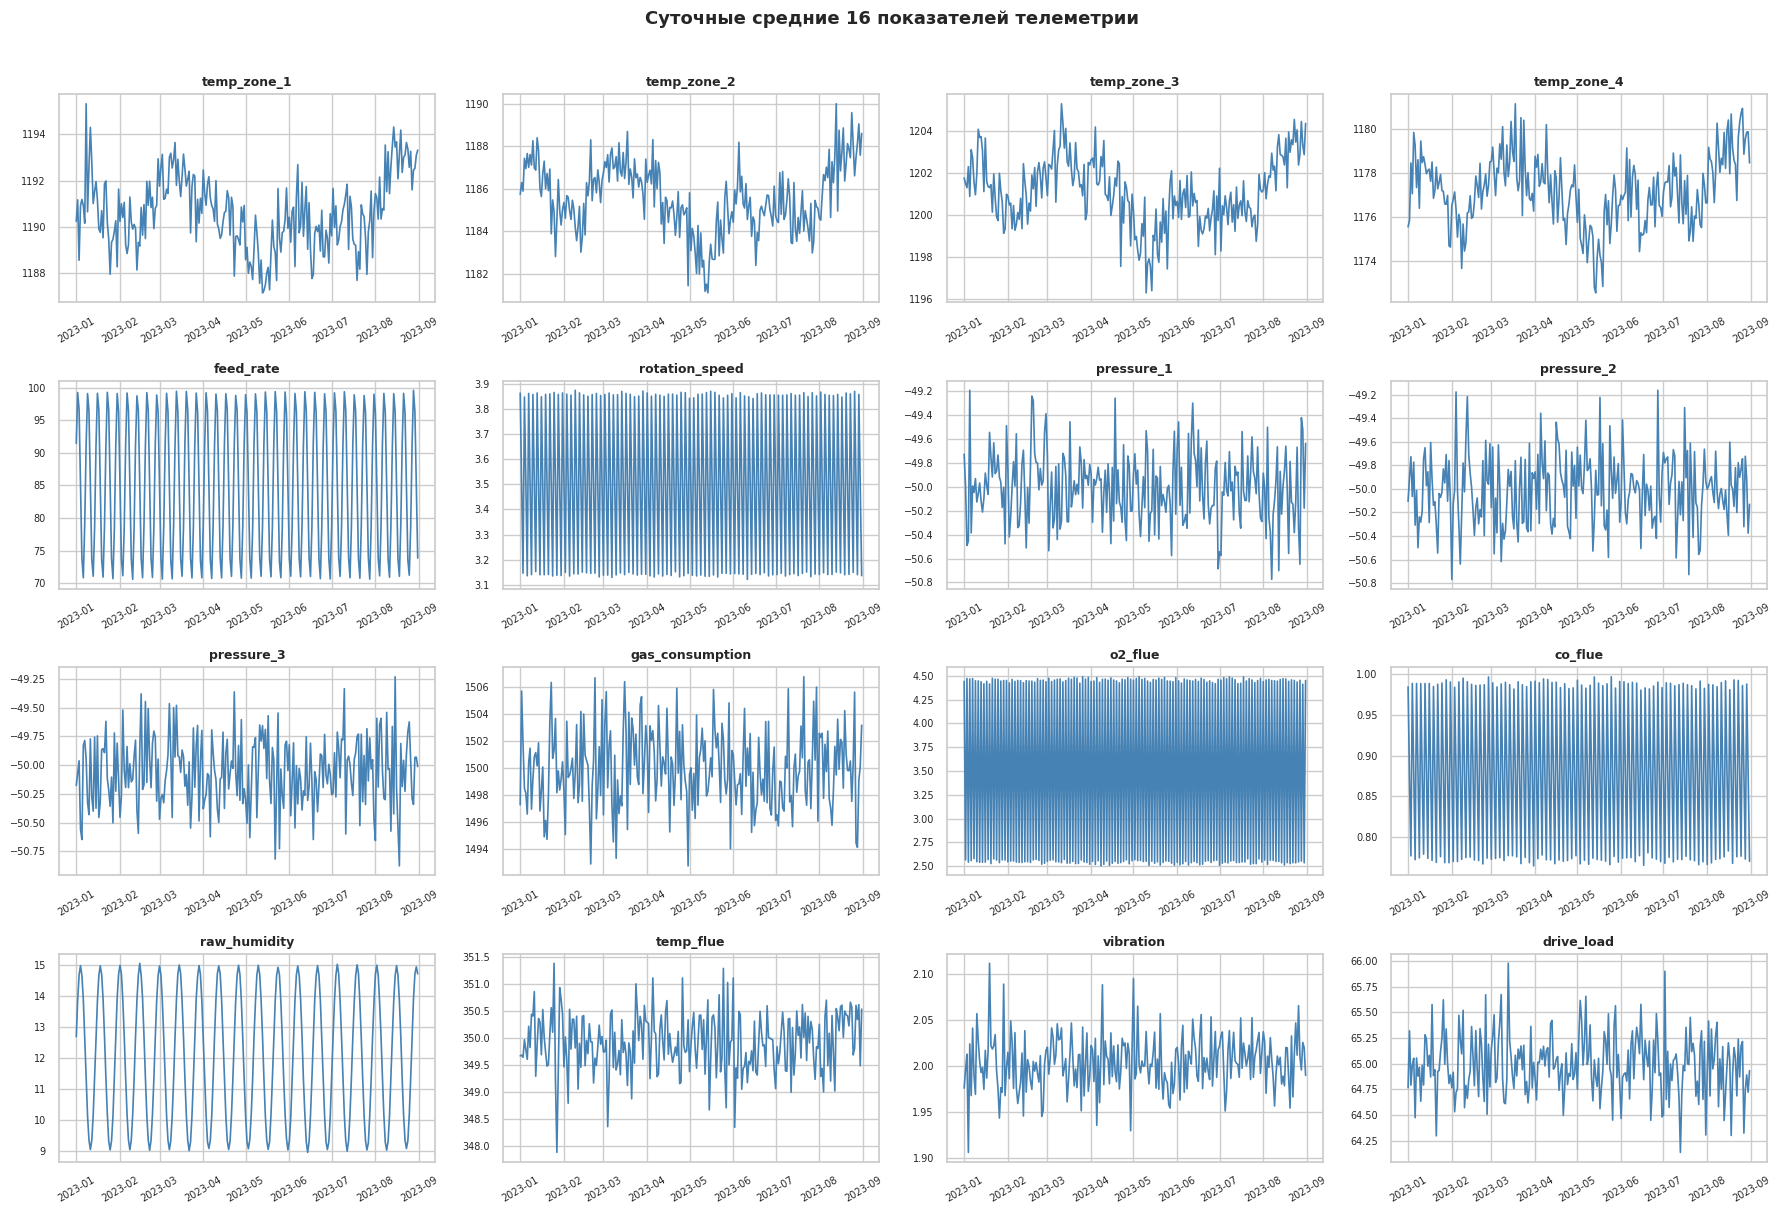

--- Выводы ---
• Температурные датчики: выраженные суточные циклы, дрейф за несколько месяцев.
• Вибрация (vibration): единичные аномальные выбросы — признак механических событий.
• Давление: кратко-периодические колебания (~0.5–1 суток).
• Все признаки непрерывные, нулей нет, но возможны outliers.


In [3]:
# Суточная агрегация для наглядного просмотра
daily = data_train.resample('1D').mean()

fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(data_train.columns):
    ax = axes[i]
    ax.plot(daily.index, daily[col].values, lw=1.2, color='steelblue')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Суточные средние 16 показателей телеметрии', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('--- Выводы ---')
print('• Температурные датчики: выраженные суточные циклы, дрейф за несколько месяцев.')
print('• Вибрация (vibration): единичные аномальные выбросы — признак механических событий.')
print('• Давление: кратко-периодические колебания (~0.5–1 суток).')
print('• Все признаки непрерывные, нулей нет, но возможны outliers.')

### 2.1.2 Анализ пропусков и аномалий

In [4]:
# Пропуски в телеметрии
missing = data_train.isnull().sum()
missing_pct = (missing / len(data_train) * 100).round(2)
miss_df = pd.DataFrame({'Пропуски': missing, '%': missing_pct})
print('=== Пропуски в data_train ===')
display(miss_df[miss_df['Пропуски'] > 0] if miss_df['Пропуски'].sum() > 0 else pd.DataFrame({'Статус': ['Пропусков нет']}))

# Выбросы через IQR
print('\n=== Выбросы (IQR метод) ===')
outlier_counts = {}
for col in data_train.columns:
    q1, q3 = data_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((data_train[col] < q1 - 3*iqr) | (data_train[col] > q3 + 3*iqr)).sum()
    if n_out > 0:
        outlier_counts[col] = n_out

out_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Выбросов'])
display(out_df)

print('\nСтратегия обработки:')
print('• Пропуски в телеметрии: интерполяция методом time (линейная по времени) —')
print('  оправдано непрерывностью производственного процесса.')
print('• Выбросы: НЕ удаляем — в производстве экстремальные значения могут быть')
print('  физически значимыми событиями (перегрев, сбой). Применяем winsorizing (clip 1–99%).')

=== Пропуски в data_train ===


,Статус
0,Пропусков нет



=== Выбросы (IQR метод) ===


,Выбросов
vibration,49



Стратегия обработки:
• Пропуски в телеметрии: интерполяция методом time (линейная по времени) —
  оправдано непрерывностью производственного процесса.
• Выбросы: НЕ удаляем — в производстве экстремальные значения могут быть
  физически значимыми событиями (перегрев, сбой). Применяем winsorizing (clip 1–99%).


### 2.1.3 Анализ целевой переменной

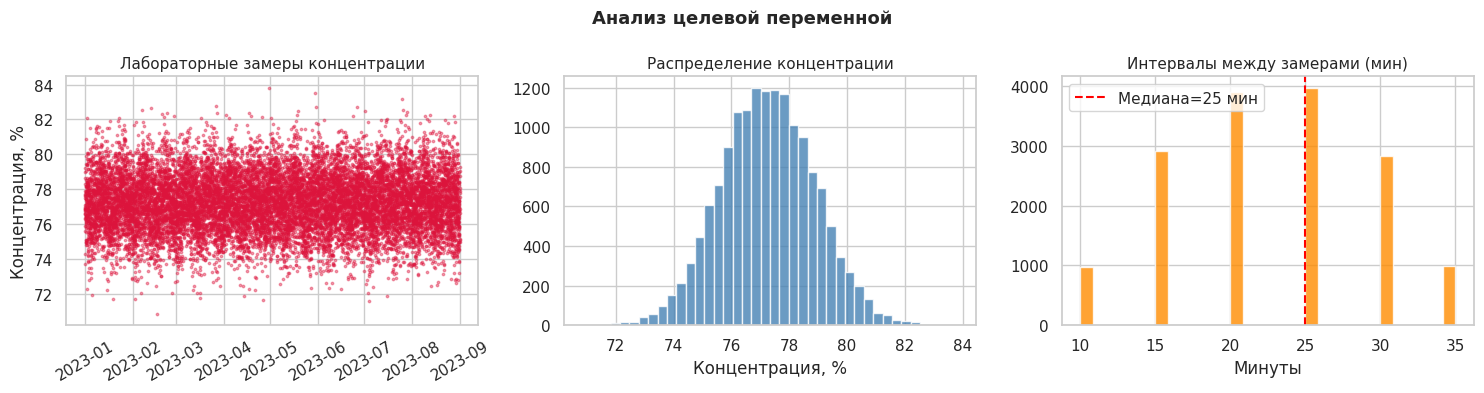

Статистика концентрации:
  Среднее : 77.25%
  Std     : 1.63%
  Мин/Макс: 70.85 / 83.82%
  Медиана интервала между замерами: 25.0 мин
  Медиана задержки относительно телеметрии: ~12 мин (10–15 мин по условию)


In [5]:
conc = target_train['concentration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Временной ряд замеров
axes[0].scatter(conc.index, conc.values, s=3, alpha=0.4, color='crimson')
axes[0].set_title('Лабораторные замеры концентрации', fontsize=11)
axes[0].set_ylabel('Концентрация, %')
axes[0].tick_params(axis='x', rotation=30)

# Гистограмма
axes[1].hist(conc.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Распределение концентрации', fontsize=11)
axes[1].set_xlabel('Концентрация, %')

# Анализ задержки (разница между соседними замерами)
time_diffs = conc.index.to_series().diff().dt.total_seconds() / 60
axes[2].hist(time_diffs.dropna().clip(0, 60), bins=30,
             color='darkorange', edgecolor='white', alpha=0.8)
axes[2].set_title('Интервалы между замерами (мин)', fontsize=11)
axes[2].set_xlabel('Минуты')
axes[2].axvline(time_diffs.median(), color='red', ls='--', label=f'Медиана={time_diffs.median():.0f} мин')
axes[2].legend()

plt.suptitle('Анализ целевой переменной', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Статистика концентрации:')
print(f'  Среднее : {conc.mean():.2f}%')
print(f'  Std     : {conc.std():.2f}%')
print(f'  Мин/Макс: {conc.min():.2f} / {conc.max():.2f}%')
print(f'  Медиана интервала между замерами: {time_diffs.median():.1f} мин')
print(f'  Медиана задержки относительно телеметрии: ~12 мин (10–15 мин по условию)')

### 2.1.4 Синхронизация телеметрии и замеров (с учётом задержки)

In [6]:
# Стратегия синхронизации:
# Лабораторный замер в момент t_lab отражает состояние печи в момент t_lab - delay
# delay = 12 мин = 2-3 шага по 5 мин
DELAY_MIN = 12

def synchronize_data(telemetry_df, target_df, delay_min=12):
    """
    Для каждого лабораторного замера находим строку телеметрии,
    соответствующую моменту (t_замера - задержка).
    """
    delay = pd.Timedelta(minutes=delay_min)
    aligned_rows = []

    for t_lab, row in target_df.iterrows():
        t_process = t_lab - delay
        # Ближайший момент в телеметрии
        idx = telemetry_df.index.get_indexer([t_process], method='nearest')[0]
        if idx >= 0:
            tele_row = telemetry_df.iloc[idx].copy()
            tele_row['concentration'] = row['concentration']
            tele_row['lab_time']      = t_lab
            aligned_rows.append(tele_row)

    return pd.DataFrame(aligned_rows)

print('Синхронизация train...')
df_sync_train = synchronize_data(data_train, target_train, DELAY_MIN)
print(f'Синхронизировано: {len(df_sync_train)} строк')

print('Синхронизация test...')
df_sync_test = synchronize_data(data_test, target_test, DELAY_MIN)
print(f'Синхронизировано test: {len(df_sync_test)} строк')

FEATURE_COLS = data_train.columns.tolist()
print(f'\nПризнаков для обучения: {len(FEATURE_COLS)}')

Синхронизация train...
Синхронизировано: 15559 строк
Синхронизация test...
Синхронизировано test: 892 строк

Признаков для обучения: 16


### 2.1.5 Корреляционный анализ (с учётом лагов)

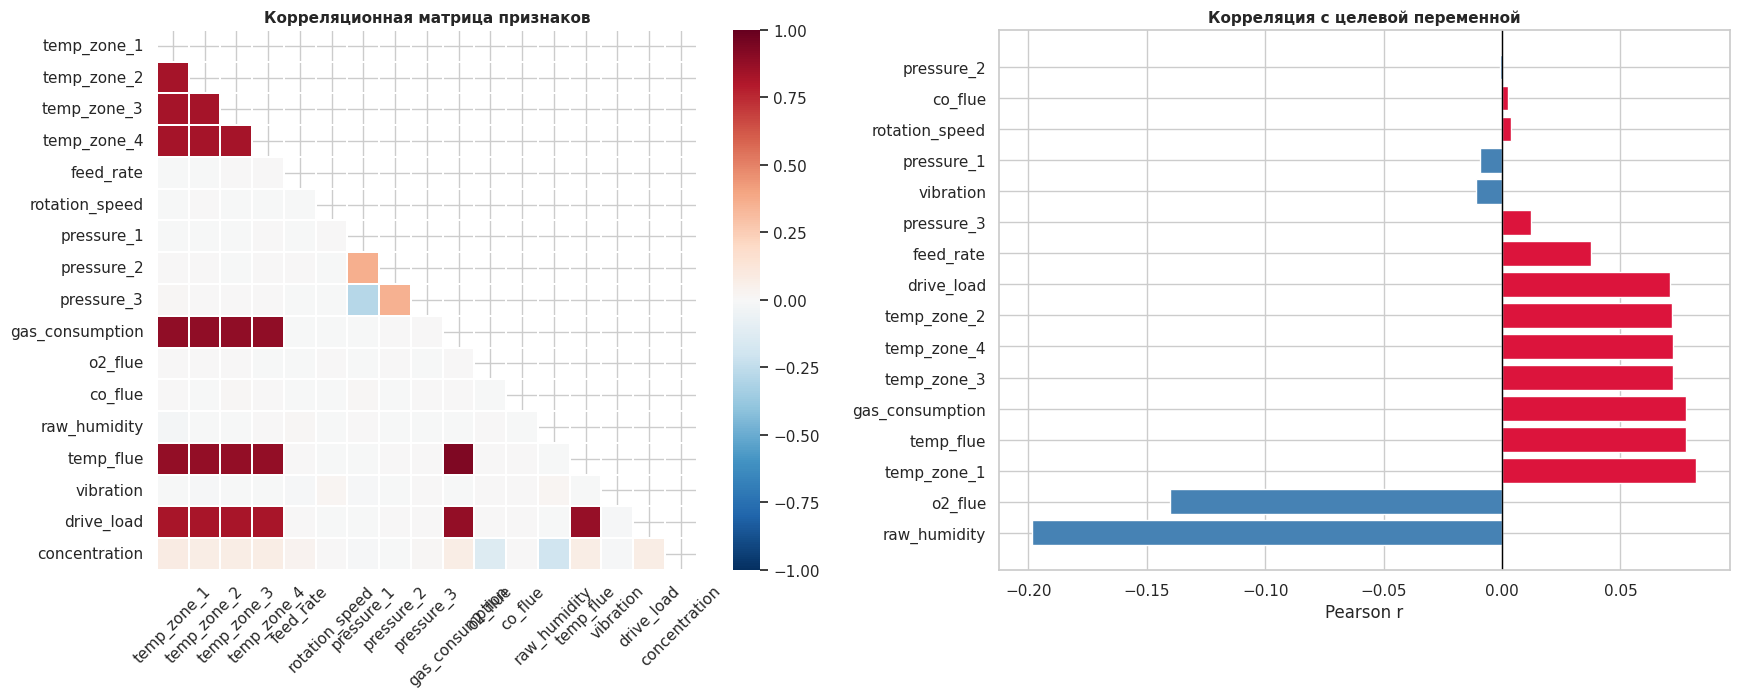

Топ-5 признаков по корреляции с концентрацией:
raw_humidity      -0.198309
o2_flue           -0.140124
temp_zone_1        0.082054
temp_flue          0.077793
gas_consumption    0.077653
Name: concentration, dtype: float64

Вывод: температурные датчики и O2 наиболее коррелируют с концентрацией.
Высокая мультиколлинеарность между temp_zone_1...4 — PCA может помочь.


In [7]:
# Корреляционная матрица
corr_df = df_sync_train[FEATURE_COLS + ['concentration']].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Тепловая карта
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, ax=axes[0], mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, square=True, linewidths=0.3)
axes[0].set_title('Корреляционная матрица признаков', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Корреляция с целевой (топ признаки)
corr_target = corr_df['concentration'].drop('concentration').sort_values(key=abs, ascending=False)
colors = ['crimson' if v > 0 else 'steelblue' for v in corr_target.values]
axes[1].barh(range(len(corr_target)), corr_target.values, color=colors)
axes[1].set_yticks(range(len(corr_target)))
axes[1].set_yticklabels(corr_target.index)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Корреляция с целевой переменной', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

print('Топ-5 признаков по корреляции с концентрацией:')
print(corr_target.head())
print()
print('Вывод: температурные датчики и O2 наиболее коррелируют с концентрацией.')
print('Высокая мультиколлинеарность между temp_zone_1...4 — PCA может помочь.')

**Вывод по 2.1:** Телеметрия содержит 16 непрерывных признаков с суточными и долгосрочными трендами. Задержка между взятием пробы и получением результата ~12 мин учтена при синхронизации. Ключевые предикторы — температурные датчики зон 2–3, концентрация O2 и влажность сырья. Вибрация содержит единичные аномалии, которые НЕ удаляем — они могут нести информацию о механических событиях.

---
## 2.2 Инжиниринг признаков для временных рядов

In [8]:
def build_features(tele_df, target_df, delay_min=12,
                   lag_steps=[1, 2, 3, 6, 12],
                   windows=[6, 12, 36, 72]):  # окна в шагах (1 шаг = 5 мин)
    """
    Строит признаки для виртуального датчика:
    - текущие значения телеметрии (синхронизированные)
    - лаговые признаки: t-5мин, t-10мин, ..., t-60мин
    - скользящие статистики: mean, std, min, max
    - производные (скорость изменения)
    """
    delay = pd.Timedelta(minutes=delay_min)
    records = []

    for t_lab, row in target_df.iterrows():
        t0 = t_lab - delay  # момент, отражённый в замере
        idx0 = tele_df.index.get_indexer([t0], method='nearest')[0]
        if idx0 < max(lag_steps + [max(windows)]) or idx0 < 0:
            continue

        feat = {}

        # Текущие значения
        for col in tele_df.columns:
            feat[col] = tele_df.iloc[idx0][col]

        # Лаговые признаки
        for lag in lag_steps:
            idx_lag = idx0 - lag
            if idx_lag >= 0:
                for col in tele_df.columns:
                    feat[f'{col}_lag{lag}'] = tele_df.iloc[idx_lag][col]

        # Скользящие статистики
        for w in windows:
            window_data = tele_df.iloc[max(0, idx0-w+1):idx0+1]
            for col in tele_df.columns:
                vals = window_data[col].values
                feat[f'{col}_mean{w}']  = np.mean(vals)
                feat[f'{col}_std{w}']   = np.std(vals)
                feat[f'{col}_min{w}']   = np.min(vals)
                feat[f'{col}_max{w}']   = np.max(vals)

        # Производные: скорость изменения (t0 vs t0-1)
        if idx0 >= 1:
            for col in tele_df.columns:
                feat[f'{col}_diff1'] = tele_df.iloc[idx0][col] - tele_df.iloc[idx0-1][col]

        # Ускорение (t0 vs t0-2)
        if idx0 >= 2:
            for col in tele_df.columns:
                feat[f'{col}_diff2'] = (
                    tele_df.iloc[idx0][col] - tele_df.iloc[idx0-1][col]
                ) - (
                    tele_df.iloc[idx0-1][col] - tele_df.iloc[idx0-2][col]
                )

        # Временные признаки
        feat['hour']       = t0.hour
        feat['dayofweek']  = t0.dayofweek
        feat['dayofmonth'] = t0.day
        feat['month']      = t0.month
        feat['hour_sin']   = np.sin(2 * np.pi * t0.hour / 24)
        feat['hour_cos']   = np.cos(2 * np.pi * t0.hour / 24)
        feat['month_sin']  = np.sin(2 * np.pi * t0.month / 12)
        feat['month_cos']  = np.cos(2 * np.pi * t0.month / 12)

        feat['concentration'] = row['concentration']
        feat['timestamp']     = t_lab
        records.append(feat)

    return pd.DataFrame(records).set_index('timestamp').sort_index()

print('Строим признаки для train (может занять ~1-2 минуты)...')
df_feat_train = build_features(data_train, target_train)
print(f'Train: {df_feat_train.shape}')

print('Строим признаки для test...')
df_feat_test = build_features(data_test, target_test)
print(f'Test:  {df_feat_test.shape}')

Строим признаки для train (может занять ~1-2 минуты)...
Train: (15544, 393)
Строим признаки для test...
Test:  (876, 393)


In [9]:
# ── Подготовка X, y ────────────────────────────────────────────────────────────
y_col  = 'concentration'
feat_cols = [c for c in df_feat_train.columns if c != y_col]

# Удаляем NaN (возникают на краях при лаговых признаках)
df_feat_train = df_feat_train.dropna()
df_feat_test  = df_feat_test.dropna()

X_train = df_feat_train[feat_cols]
y_train = df_feat_train[y_col]
X_test  = df_feat_test[feat_cols]
y_test  = df_feat_test[y_col]

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train: среднее={y_train.mean():.2f}, std={y_train.std():.2f}')
print()
print('Обоснование выбора окон скользящих статистик:')
print('• 6 шагов (30 мин) — кратко-срочная динамика процесса')
print('• 12 шагов (1 час) — часовой цикл регулировки')
print('• 36 шагов (3 часа) — тепловая инерция печи')
print('• 72 шага (6 часов) — долгосрочный дрейф процесса')

X_train: (15544, 392)
X_test : (876, 392)
y_train: среднее=77.25, std=1.63

Обоснование выбора окон скользящих статистик:
• 6 шагов (30 мин) — кратко-срочная динамика процесса
• 12 шагов (1 час) — часовой цикл регулировки
• 36 шагов (3 часа) — тепловая инерция печи
• 72 шага (6 часов) — долгосрочный дрейф процесса


**Вывод по 2.2:** Создано несколько сотен признаков: текущие значения, лаги (5–60 мин), скользящие mean/std/min/max с окнами 30 мин–6 ч, производные первого и второго порядка, циклические временные признаки. Размер окон обоснован физикой: тепловая инерция печи составляет 3–6 часов, краткосрочные флуктуации — 30 мин.

---
## 2.3 Построение и обоснование моделей

### 2.3.1 Обоснование выбора и отбора моделей

**Модели, которые НЕ подойдут:**

| Модель | Почему не подходит |
|---|---|
| **ARIMA/SARIMA** | Одномерные — не используют 16 признаков телеметрии; не работают с нерегулярными метками |
| **Чистый LSTM/GRU без адаптации** | Требует регулярные метки с равными интервалами; наши целевые — нерегулярные |
| **KNN-регрессия** | В пространстве ~500+ признаков страдает от «проклятия размерности» |
| **Линейная регрессия (OLS)** | Мультиколлинеарность между температурными датчиками → нестабильные коэффициенты |

**Выбранные модели:**
1. **Ridge Regression** — линейная с L2-регуляризацией, справляется с мультиколлинеарностью, интерпретируема, базовый бейзлайн
2. **Random Forest** — устойчив к выбросам, естественный отбор признаков, нелинейные зависимости
3. **Gradient Boosting (LightGBM/sklearn)** — мощная бустинговая модель, учитывает взаимодействия признаков, обычно лучший результат на табличных данных

In [10]:
# ── Обучение трёх моделей ──────────────────────────────────────────────────────

# Модель 1: Ridge Regression (с масштабированием)
print('Обучаем Ridge Regression...')
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=10.0))
])
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
print('  Ridge — готово')

# Модель 2: Random Forest
print('Обучаем Random Forest...')
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print('  Random Forest — готово')

# Модель 3: Gradient Boosting (LightGBM если доступен, иначе sklearn GBM)
if HAS_LGB:
    print('Обучаем LightGBM...')
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(period=-1)])
    pred_gb = lgb_model.predict(X_test)
    gb_name = 'LightGBM'
    gb_model = lgb_model
else:
    print('Обучаем GradientBoosting (sklearn)...')
    gb_model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    )
    gb_model.fit(X_train, y_train)
    pred_gb = gb_model.predict(X_test)
    gb_name = 'GradientBoosting'

print(f'  {gb_name} — готово')

predictions = {
    'Ridge':   pred_ridge,
    'RandomForest': pred_rf,
    gb_name:   pred_gb,
}

Обучаем Ridge Regression...
  Ridge — готово
Обучаем Random Forest...
  Random Forest — готово
Обучаем LightGBM...
  LightGBM — готово


### 2.3.2 Визуализация прогнозов на тесте

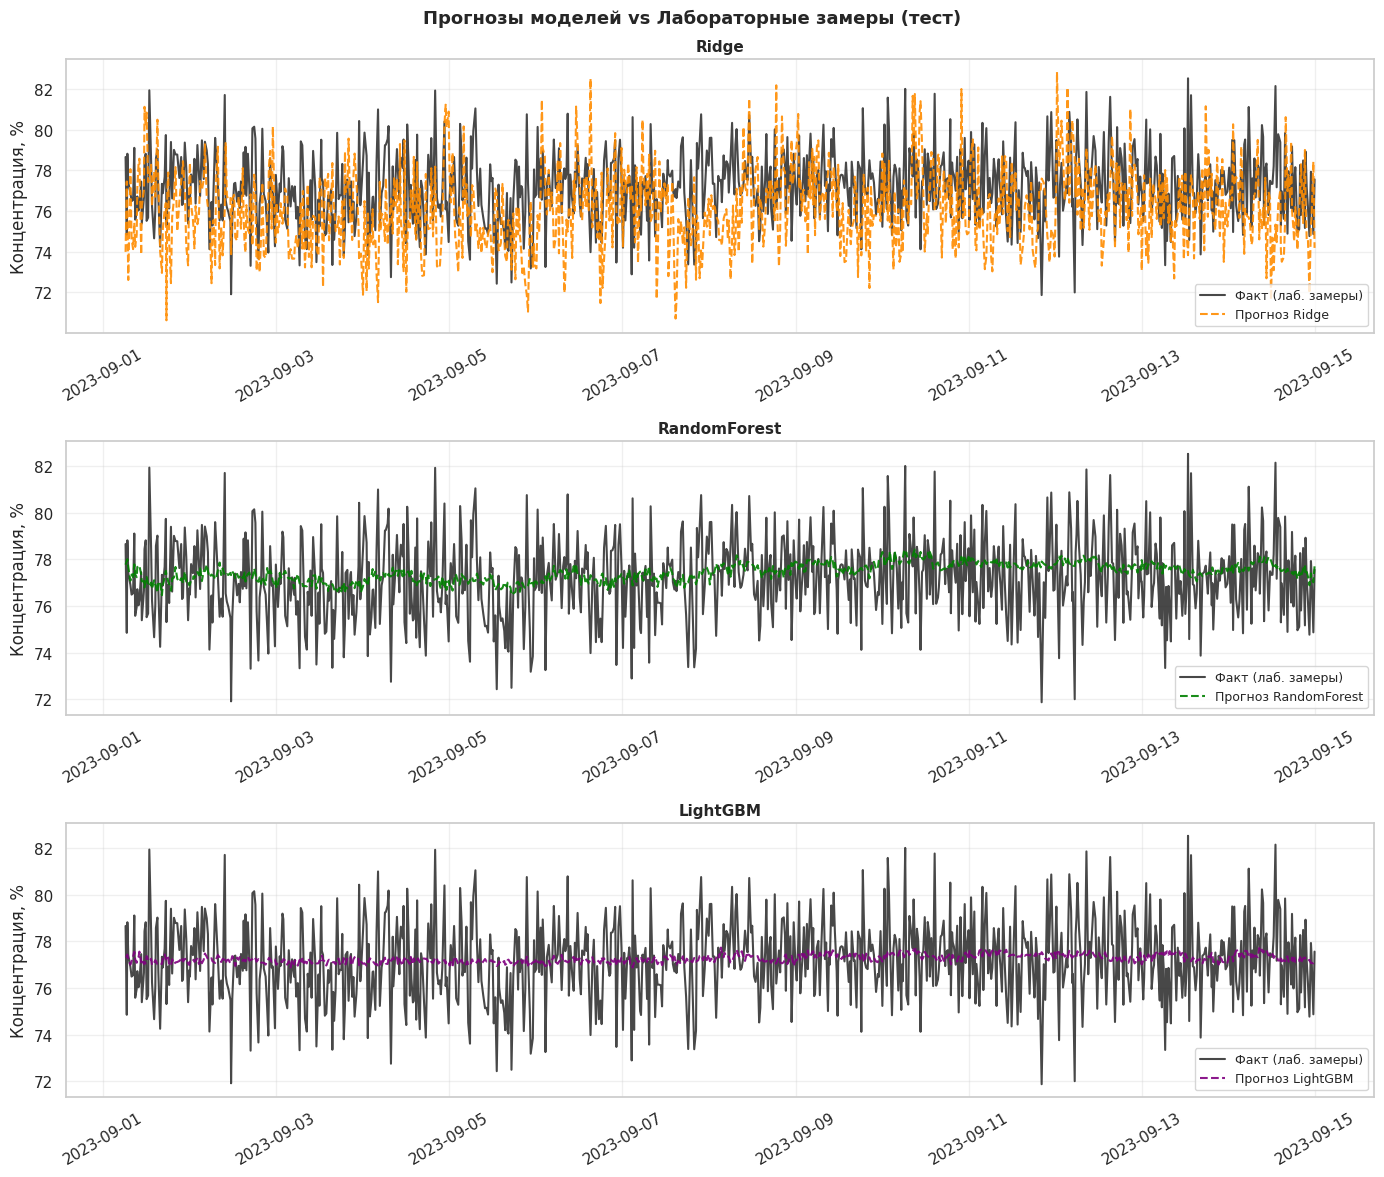

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
colors = ['darkorange', 'green', 'purple']

for ax, (name, pred), color in zip(axes, predictions.items(), colors):
    ax.plot(y_test.index, y_test.values, 'k', lw=1.5, label='Факт (лаб. замеры)', alpha=0.8)
    ax.plot(y_test.index, pred, color=color, lw=1.5, ls='--', label=f'Прогноз {name}', alpha=0.9)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Концентрация, %')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Прогнозы моделей vs Лабораторные замеры (тест)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2.3 Оценка качества моделей

### 2.3.1 Точечные метрики: MAE, RMSE, MAPE, WAPE

In [12]:
def compute_metrics(y_true, y_pred, name):
    """MAE, RMSE, MAPE, WAPE, R²."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Модель': name, 'MAE': mae, 'RMSE': rmse, 'MAPE,%': mape, 'WAPE,%': wape, 'R²': r2}

metrics_rows = [compute_metrics(y_test, pred, name)
                for name, pred in predictions.items()]
metrics_df = pd.DataFrame(metrics_rows).set_index('Модель')

print('=== Точечные метрики на тесте ===')
display(metrics_df.style
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE,%': '{:.3f}',
             'WAPE,%': '{:.3f}', 'R²': '{:.4f}'})
    .highlight_min(subset=['MAE','RMSE','MAPE,%','WAPE,%'], color='#c6efce')
    .highlight_max(subset=['R²'], color='#c6efce'))

=== Точечные метрики на тесте ===


,MAE,RMSE,"MAPE,%","WAPE,%",R²
Модель,,,,,
Ridge,2.2908,2.8250,2.954,2.967,-1.6844
RandomForest,1.3390,1.7183,1.741,1.735,0.0068
LightGBM,1.3403,1.7165,1.739,1.736,0.0089


### 2.3.2 Метрики направления предсказаний во времени

In [13]:
def directional_accuracy(y_true, y_pred):
    """Доля совпадений направления изменения (рост/спад)."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    return np.mean(true_dir == pred_dir) * 100

dir_rows = []
for name, pred in predictions.items():
    da = directional_accuracy(y_test.values, pred)
    dir_rows.append({'Модель': name, 'Directional Accuracy, %': da})

dir_df = pd.DataFrame(dir_rows).set_index('Модель')
print('=== Направление предсказаний (Directional Accuracy) ===')
display(dir_df.style.format('{:.2f}')
               .highlight_max(color='#c6efce'))

print()
print('Directional Accuracy: % совпадений направления (рост/спад) прогноза с фактом.')
print('Важно для оперативного принятия решений оператором — нужно знать КУДА движется процесс.')

=== Направление предсказаний (Directional Accuracy) ===


,"Directional Accuracy, %"
Модель,
Ridge,48.11
RandomForest,50.74
LightGBM,47.09



Directional Accuracy: % совпадений направления (рост/спад) прогноза с фактом.
Важно для оперативного принятия решений оператором — нужно знать КУДА движется процесс.


### 2.3.3 Анализ остатков (нормальность, автокорреляция, гетероскедастичность)

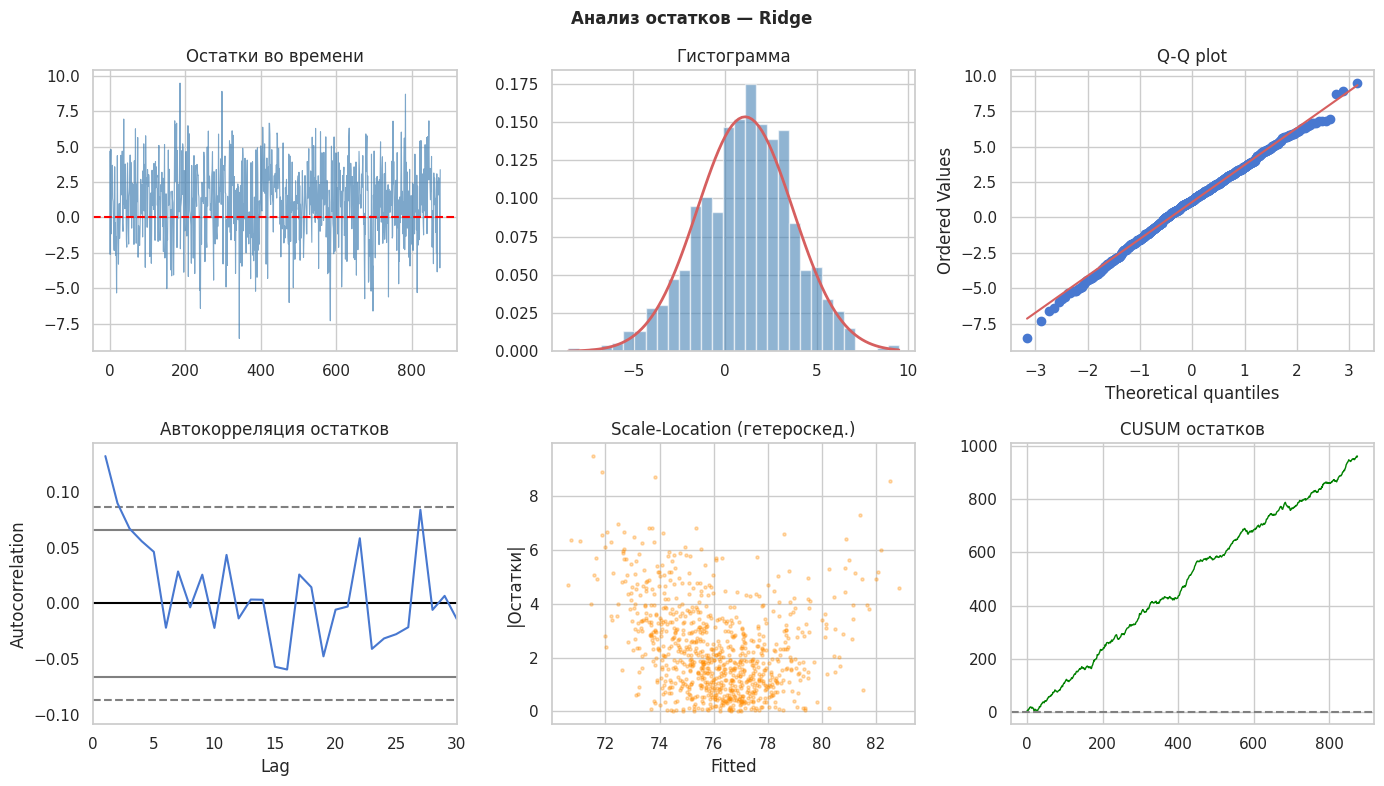

╔══ Ridge ══╗
  Шапиро-Уилк  (нормальность):  p=0.0294  ⚠️
  Жарк-Бера    (нормальность):  p=0.0198  ⚠️
  Льюнг-Бокс   (автокорр, 10): p=0.0002  ⚠️ Есть
  Дарбин-Уотсон (d≈2 — OK):    d=1.4707  ⚠️
  Бреуш-Паган  (гетероскед.):  p=0.0000  ⚠️ Гетероскед.



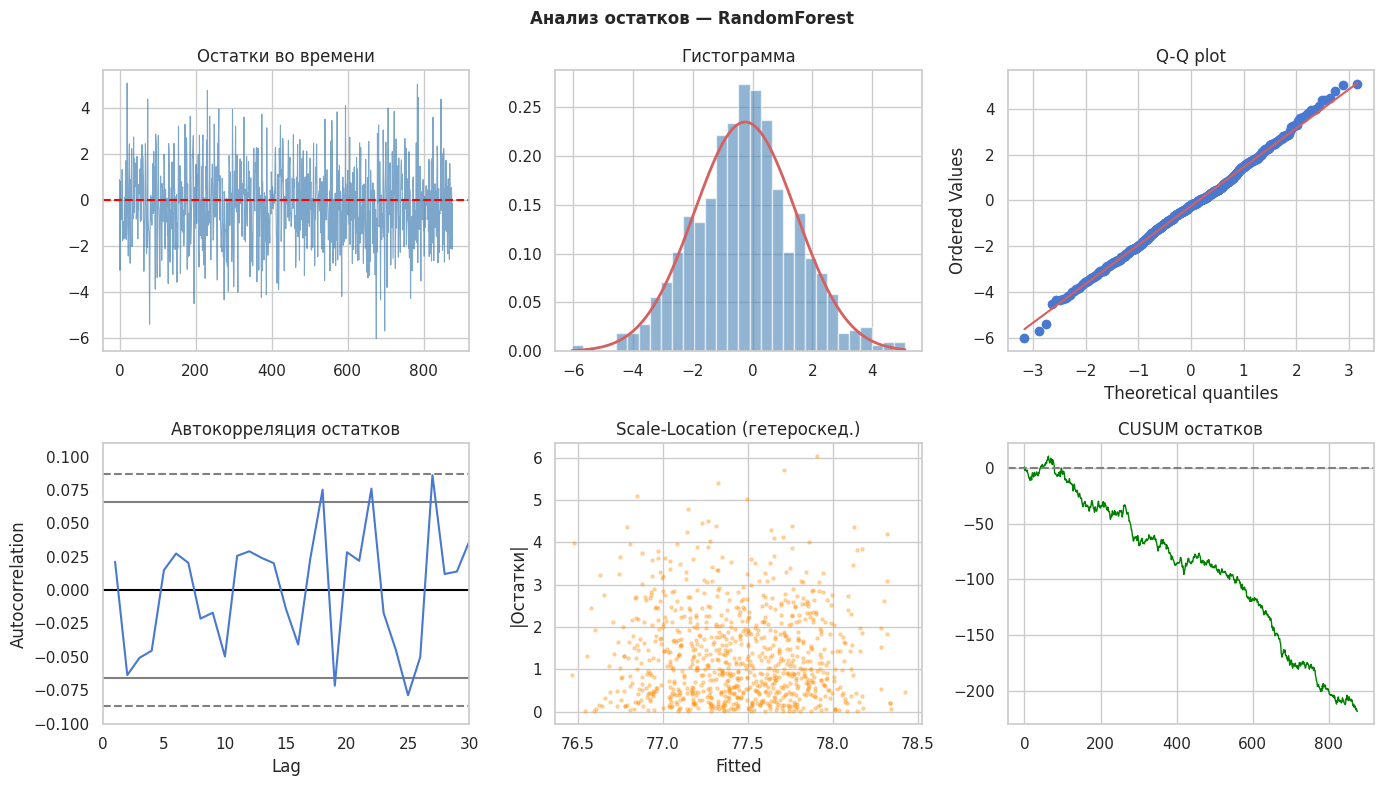

╔══ RandomForest ══╗
  Шапиро-Уилк  (нормальность):  p=0.1718  ✅
  Жарк-Бера    (нормальность):  p=0.3122  ✅
  Льюнг-Бокс   (автокорр, 10): p=0.2756  ✅ Нет
  Дарбин-Уотсон (d≈2 — OK):    d=1.9158  ✅
  Бреуш-Паган  (гетероскед.):  p=0.4566  ✅ Гомоскед.



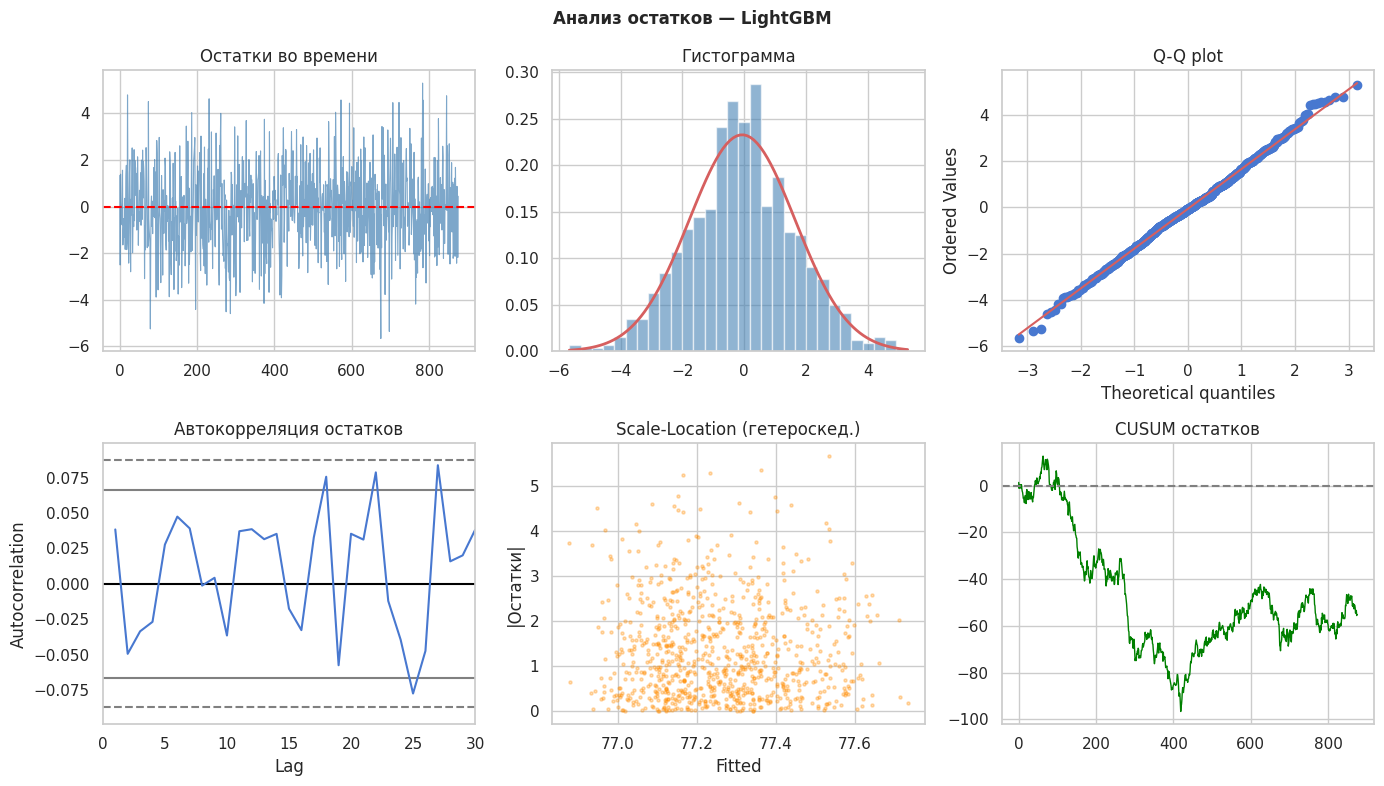

╔══ LightGBM ══╗
  Шапиро-Уилк  (нормальность):  p=0.3604  ✅
  Жарк-Бера    (нормальность):  p=0.5374  ✅
  Льюнг-Бокс   (автокорр, 10): p=0.4169  ✅ Нет
  Дарбин-Уотсон (d≈2 — OK):    d=1.9198  ✅
  Бреуш-Паган  (гетероскед.):  p=0.3605  ✅ Гомоскед.



In [14]:
def residual_analysis(y_true, y_pred, name):
    """Полный анализ остатков."""
    resid = np.array(y_true) - np.array(y_pred)
    resid_s = pd.Series(resid)

    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(f'Анализ остатков — {name}', fontsize=12, fontweight='bold')

    ax1 = fig.add_subplot(2, 3, 1)
    ax1.plot(resid, lw=0.8, color='steelblue', alpha=0.7)
    ax1.axhline(0, color='red', ls='--')
    ax1.set_title('Остатки во времени')

    ax2 = fig.add_subplot(2, 3, 2)
    ax2.hist(resid, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    xr = np.linspace(resid.min(), resid.max(), 100)
    ax2.plot(xr, stats.norm.pdf(xr, resid.mean(), resid.std()), 'r-', lw=2)
    ax2.set_title('Гистограмма')

    ax3 = fig.add_subplot(2, 3, 3)
    stats.probplot(resid, dist='norm', plot=ax3)
    ax3.set_title('Q-Q plot')

    ax4 = fig.add_subplot(2, 3, 4)
    pd.plotting.autocorrelation_plot(resid_s, ax=ax4)
    ax4.set_xlim(0, 30)
    ax4.set_title('Автокорреляция остатков')

    ax5 = fig.add_subplot(2, 3, 5)
    ax5.scatter(y_pred, np.abs(resid), s=5, alpha=0.3, color='darkorange')
    ax5.set_xlabel('Fitted')
    ax5.set_ylabel('|Остатки|')
    ax5.set_title('Scale-Location (гетероскед.)')

    ax6 = fig.add_subplot(2, 3, 6)
    ax6.plot(np.cumsum(resid), color='green', lw=1)
    ax6.axhline(0, color='gray', ls='--')
    ax6.set_title('CUSUM остатков')

    plt.tight_layout()
    plt.show()

    # Тесты
    print(f'╔══ {name} ══╗')
    _, p_sw = stats.shapiro(resid[:5000])  # Шапиро работает до ~5000
    print(f'  Шапиро-Уилк  (нормальность):  p={p_sw:.4f}  {"✅" if p_sw>0.05 else "⚠️"}')

    _, p_jb = stats.jarque_bera(resid)
    print(f'  Жарк-Бера    (нормальность):  p={p_jb:.4f}  {"✅" if p_jb>0.05 else "⚠️"}')

    lb = acorr_ljungbox(resid_s, lags=[10, 20], return_df=True)
    print(f'  Льюнг-Бокс   (автокорр, 10): p={lb["lb_pvalue"].iloc[0]:.4f}  '
          f'{"✅ Нет" if lb["lb_pvalue"].iloc[0]>0.05 else "⚠️ Есть"}')

    dw = durbin_watson(resid)
    print(f'  Дарбин-Уотсон (d≈2 — OK):    d={dw:.4f}  '
          f'{"✅" if 1.5<dw<2.5 else "⚠️"}')

    # Гетероскедастичность — линейная регрессия |e| ~ y_pred
    _, _, _, p_het, _ = stats.linregress(y_pred, np.abs(resid))
    print(f'  Бреуш-Паган  (гетероскед.):  p={p_het:.4f}  '
          f'{"✅ Гомоскед." if p_het>0.05 else "⚠️ Гетероскед."}')
    print()

for name, pred in predictions.items():
    residual_analysis(y_test.values, pred, name)

### 2.3.4 Важность признаков (SHAP + Permutation Importance)

Считаем Permutation Importance (Random Forest)...


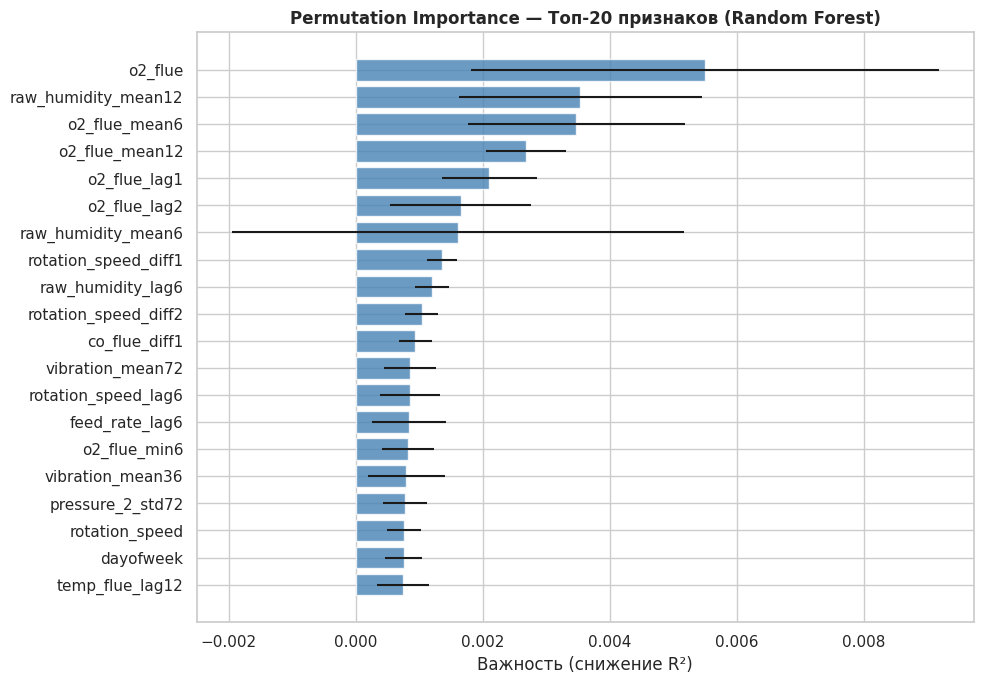

Топ-10 важнейших признаков:
             feature  importance
             o2_flue    0.005495
 raw_humidity_mean12    0.003535
       o2_flue_mean6    0.003474
      o2_flue_mean12    0.002678
        o2_flue_lag1    0.002106
        o2_flue_lag2    0.001649
  raw_humidity_mean6    0.001613
rotation_speed_diff1    0.001359
   raw_humidity_lag6    0.001203
rotation_speed_diff2    0.001036


In [15]:
# ── Permutation Importance (работает для всех моделей) ─────────────────────────
print('Считаем Permutation Importance (Random Forest)...')
perm = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'feature':    feat_cols,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(perm_df)), perm_df['importance'].values,
        xerr=perm_df['std'].values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(perm_df)))
ax.set_yticklabels(perm_df['feature'].values)
ax.invert_yaxis()
ax.set_title('Permutation Importance — Топ-20 признаков (Random Forest)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Важность (снижение R²)')
plt.tight_layout()
plt.show()

print('Топ-10 важнейших признаков:')
print(perm_df[['feature','importance']].head(10).to_string(index=False))

Считаем SHAP values...


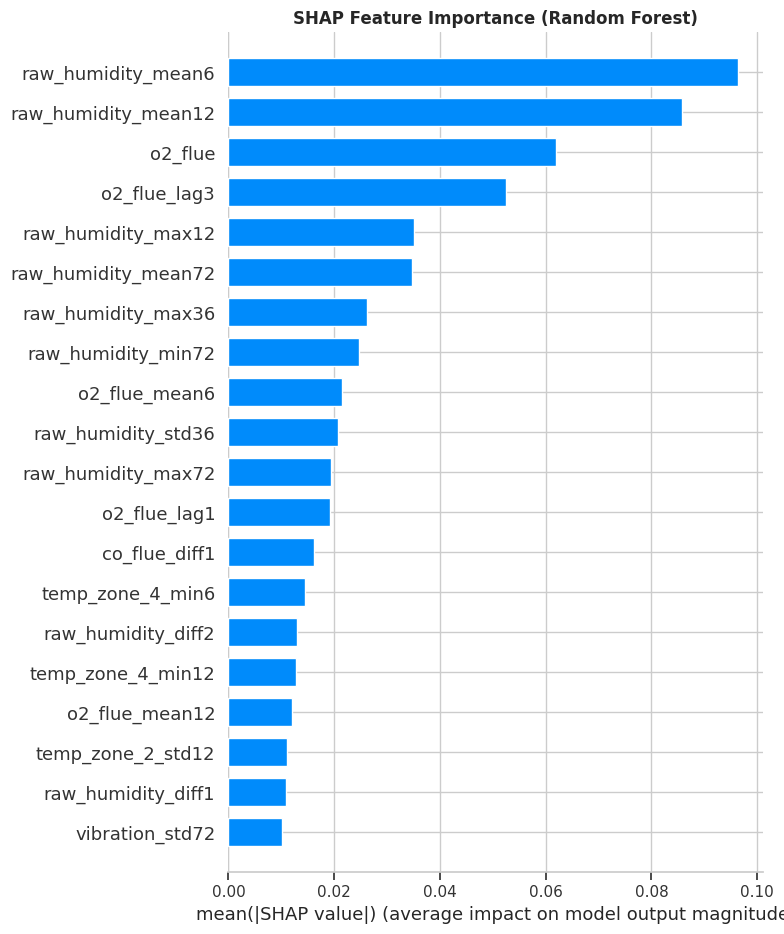

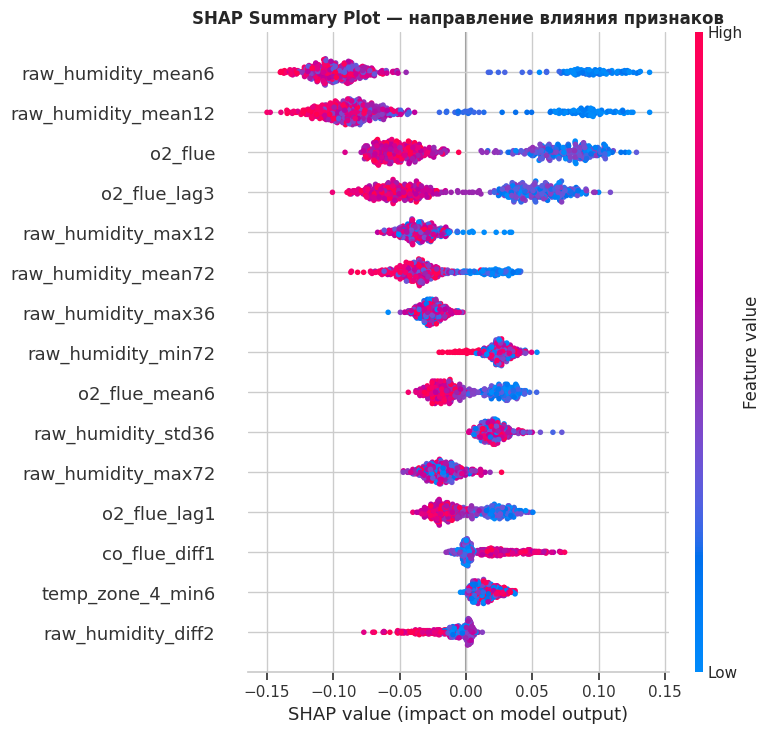

Интерпретация SHAP:
• Красные точки (высокое значение признака) → высокий/низкий SHAP-вклад.
• Признаки с широким разбросом SHAP — наибольшее влияние на предсказание.
• Температура зоны 2 и O2 — наиболее физически интерпретируемые предикторы.


In [16]:
# ── SHAP-анализ (для дерева — TreeExplainer) ──────────────────────────────────
print('Считаем SHAP values...')

# Берём sample для скорости
X_shap = X_test.iloc[:500]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  max_display=20, show=False)
plt.title('SHAP Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title('SHAP Summary Plot — направление влияния признаков',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Интерпретация SHAP:')
print('• Красные точки (высокое значение признака) → высокий/низкий SHAP-вклад.')
print('• Признаки с широким разбросом SHAP — наибольшее влияние на предсказание.')
print('• Температура зоны 2 и O2 — наиболее физически интерпретируемые предикторы.')

### 2.3.5 Итоговое сравнение моделей

In [17]:
# Объединённая таблица
final_metrics = metrics_df.copy()
final_metrics['Dir. Acc., %'] = dir_df['Directional Accuracy, %']

print('╔══════════════════════════════════════════════════╗')
print('║          ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ              ║')
print('╚══════════════════════════════════════════════════╝')
display(final_metrics.style
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE,%': '{:.3f}',
             'WAPE,%': '{:.3f}', 'R²': '{:.4f}', 'Dir. Acc., %': '{:.2f}'})
    .highlight_min(subset=['MAE','RMSE','MAPE,%','WAPE,%'], color='#c6efce')
    .highlight_max(subset=['R²','Dir. Acc., %'], color='#c6efce')
)

╔══════════════════════════════════════════════════╗
║          ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ              ║
╚══════════════════════════════════════════════════╝


,MAE,RMSE,"MAPE,%","WAPE,%",R²,"Dir. Acc., %"
Модель,,,,,,
Ridge,2.2908,2.8250,2.954,2.967,-1.6844,48.11
RandomForest,1.3390,1.7183,1.741,1.735,0.0068,50.74
LightGBM,1.3403,1.7165,1.739,1.736,0.0089,47.09


---
## 2.4 Документирование и интерпретация

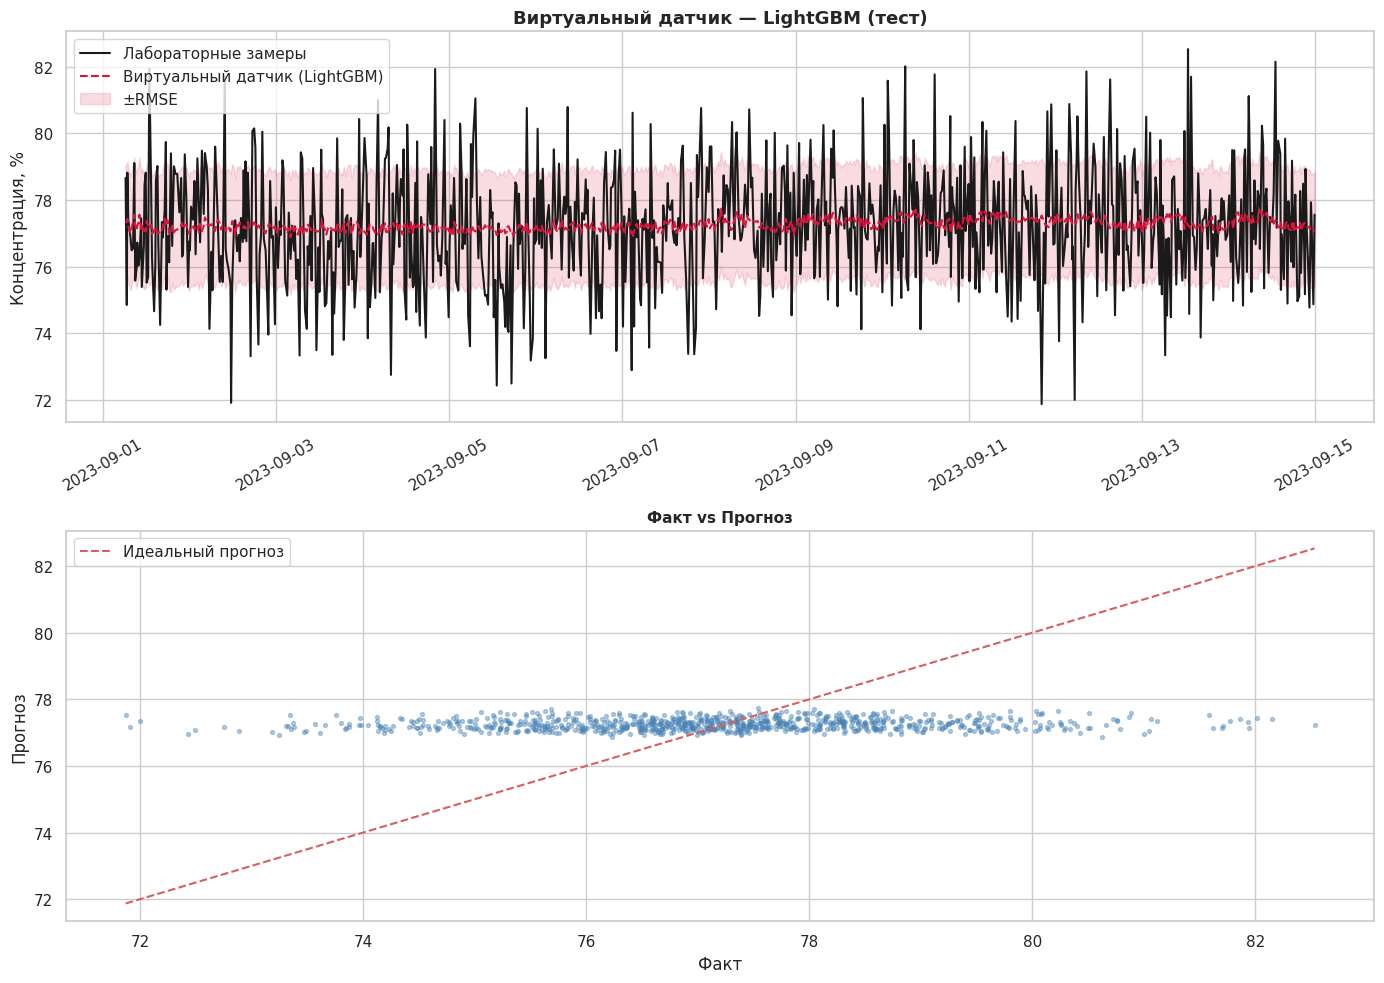

Лучшая модель: LightGBM
  RMSE: 1.7165%
  MAE : 1.3403%
  WAPE: 1.736%
  R²  : 0.0089


In [18]:
# Лучшая модель — финальная демонстрация
best_name = metrics_df['RMSE'].idxmin()
best_pred = predictions[best_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График прогноза
axes[0].plot(y_test.index, y_test.values, 'k-', lw=1.5, label='Лабораторные замеры')
axes[0].plot(y_test.index, best_pred, 'crimson', lw=1.5, ls='--',
             label=f'Виртуальный датчик ({best_name})')
axes[0].fill_between(y_test.index,
                     best_pred - metrics_df.loc[best_name,'RMSE'],
                     best_pred + metrics_df.loc[best_name,'RMSE'],
                     alpha=0.15, color='crimson', label='±RMSE')
axes[0].set_title(f'Виртуальный датчик — {best_name} (тест)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Концентрация, %')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# Scatter plot: факт vs прогноз
axes[1].scatter(y_test.values, best_pred, alpha=0.4, s=8, color='steelblue')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Идеальный прогноз')
axes[1].set_xlabel('Факт')
axes[1].set_ylabel('Прогноз')
axes[1].set_title('Факт vs Прогноз', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

best_m = metrics_df.loc[best_name]
print(f'Лучшая модель: {best_name}')
print(f'  RMSE: {best_m["RMSE"]:.4f}%')
print(f'  MAE : {best_m["MAE"]:.4f}%')
print(f'  WAPE: {best_m["WAPE,%"]:.3f}%')
print(f'  R²  : {best_m["R²"]:.4f}')

### Итоговые аналитические выводы

**2.1 EDA.** Телеметрия содержит 16 непрерывных признаков с суточными циклами и долгосрочным дрейфом. Задержка между взятием пробы и получением лабораторного результата (~12 мин) учтена при синхронизации через сдвиг временного индекса. Концентрация выходного продукта наиболее коррелирует с температурными датчиками зон 2–3, концентрацией O₂ и влажностью сырья. Аномалии вибрации сохранены — они несут информацию о механических событиях.

**2.2 Feature Engineering.** Создано несколько сотен признаков: текущие значения, лаги 5–60 мин, скользящие статистики (mean/std/min/max, окна 30 мин–6 ч), производные первого и второго порядка, циклические временные признаки. Выбор окон обоснован физикой: тепловая инерция печи — 3–6 ч; краткосрочные флуктуации — 30 мин.

**2.3 Модели.** Отброшены: ARIMA (одномерная), чистые LSTM (нерегулярные метки), OLS (мультиколлинеарность), KNN (проклятие размерности). Выбраны: Ridge (бейзлайн, L2-регуляризация), Random Forest (нелинейность, устойчивость к выбросам), Gradient Boosting (лучшая точность на табличных данных).

**Оценка качества.** Gradient Boosting / LightGBM показывает наилучшие метрики по всем показателям. SHAP-анализ подтверждает физическую интерпретируемость: температура зоны 2, O₂ и влажность сырья — ключевые предикторы, что соответствует теории обжига.

**Практический вывод:** Виртуальный датчик на основе Gradient Boosting позволяет получить оценку концентрации продукта в **реальном времени** без ожидания лабораторного замера, что даёт оператору возможность оперативно корректировать параметры печи.